# Function 8

<b> Description of the Sample Application:</b> You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 
Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.
For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this scor.




In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from scipy.stats import qmc

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Load and Analyse the Data

In [57]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X       = np.load(input_file)
y       = np.load(output_file)

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", y.shape)
print("Outputs:\n", y)
print()

print(f"y Range: [: {y.min()}, {y.max()}]")
best_idx   = np.argmax(y)
print(f"Best point: x = {X[best_idx]}, y = {y[best_idx]}")
print()

Input  Shape: (40, 8)
Inputs:
 [[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59

In [59]:
# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['y'] = y
print("Data Frame:\n", df.head())

Data Frame:
         X_1       X_2       X_3       X_4       X_5       X_6       X_7  \
0  0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311   
1  0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384   
2  0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415   
3  0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827   
4  0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295   

        X_8         y  
0  0.734281  7.398721  
1  0.107132  7.005227  
2  0.367320  8.459482  
3  0.292472  8.284008  
4  0.593882  8.606117  


# Data Exploration

In [62]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4        X_5        X_6  \
count  40.000000  40.000000  40.000000  40.000000  40.000000  40.000000   
mean    0.534609   0.472150   0.515970   0.430449   0.468951   0.460126   
std     0.310676   0.309706   0.282440   0.261479   0.281380   0.277376   
min     0.009077   0.003419   0.022929   0.009043   0.009649   0.022113   
25%     0.302376   0.206189   0.306074   0.179607   0.236969   0.245246   
50%     0.532770   0.540389   0.488684   0.470111   0.411933   0.409715   
75%     0.792979   0.712416   0.732348   0.663788   0.722449   0.706965   
max     0.985945   0.973980   0.998885   0.902986   0.986902   0.990244   

             X_7        X_8          y  
count  40.000000  40.000000  40.000000  
mean    0.579196   0.506720   7.815274  
std     0.257913   0.281347   0.958966  
min     0.035909   0.041956   5.592193  
25%     0.428796   0.294756   7.257810  
50%     0.596949   0.525116   7.8891

In [64]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())


Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
X_5    0
X_6    0
X_7    0
X_8    0
y      0
dtype: int64


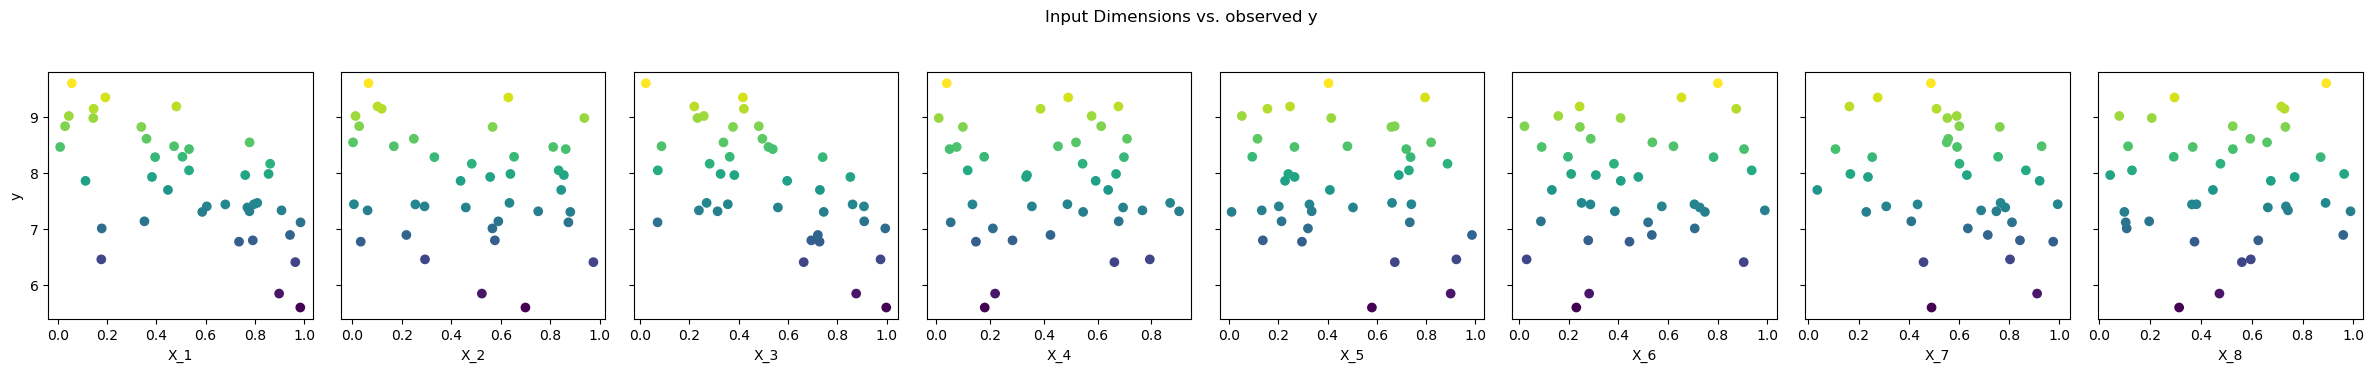

In [66]:
# Pairwise Scatter Plot, showing relationship of y for each input

fig, axes = plt.subplots(1, X.shape[1], figsize = (3 * X.shape[1], 3.5), sharey = True)
for ax, col in zip(axes, ['X_1','X_2','X_3','X_4','X_5','X_6','X_7','X_8']):
    ax.scatter(df[col], df['y'], c = df['y'], cmap = "viridis")
    ax.set_xlabel(col)
axes[0].set_ylabel('y')
plt.suptitle("Input Dimensions vs. observed y", y = 1.05)
plt.tight_layout()
plt.show()

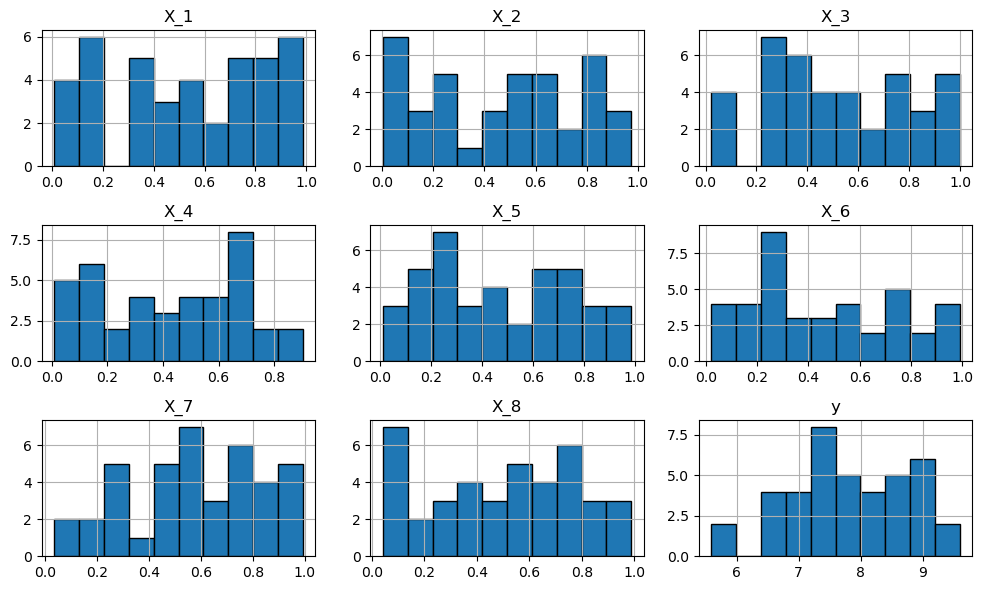

In [67]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [70]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4", "X_5", "X_6", 'X_7','X_8']
print("Correlation of each input with y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], y)[0, 1]
    print(f" corr({lab}, y) = {corr}")

Correlation of each input with y:

 corr(X_1, y) = -0.6258606500359236
 corr(X_2, y) = -0.23534905376689663
 corr(X_3, y) = -0.6228935880899082
 corr(X_4, y) = -0.07254625721608181
 corr(X_5, y) = -0.16933952013030015
 corr(X_6, y) = 0.06722692908078444
 corr(X_7, y) = -0.28926888887642566
 corr(X_8, y) = 0.05348445940733927


<Axes: >

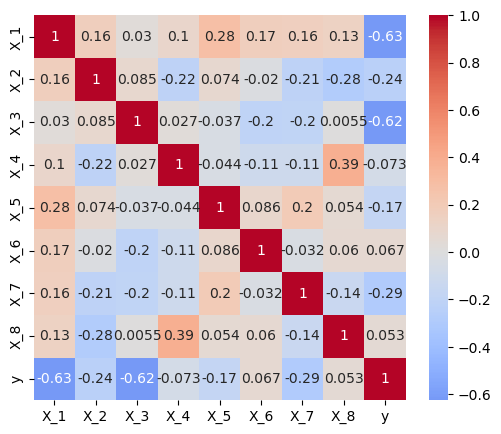

In [72]:
# Plotting the Correlation heatmap
plt.figure(figsize = (6,5))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

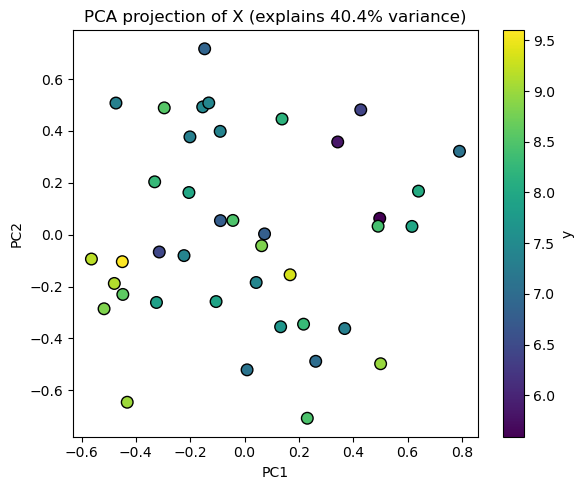

In [74]:
# Identify clustering of high-y points using PCA projection to 2D
pca  = PCA(n_components = 2)
X2   = pca.fit_transform(X)
plt.figure(figsize = (6, 5))
sc   = plt.scatter(X2[:, 0], X2[:, 1], c = y, cmap = "viridis", s = 70, edgecolor = "k")
plt.colorbar(sc, label = "y")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA projection of X (explains {pca.explained_variance_ratio_.sum()*100:.1f}% variance)")
plt.tight_layout()

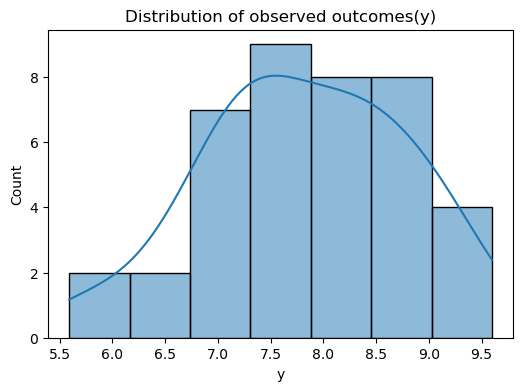

In [49]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['y'], kde = True)
plt.title("Distribution of observed outcomes(y)")
plt.show()

# Initialize Gaussian Process

In [76]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = np.ones(8), length_scale_bounds = (1e-2, 1e2)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-8, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Fit the Gaussian Processes to existing data

In [79]:
# Train the model

gpr.fit(X, y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  2.26**2 * RBF(length_scale=[1.7, 2.57, 1.4, 2.62, 6, 2.48, 1.79, 100]) + WhiteKernel(noise_level=1e-08)


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [86]:
# Setting a higher beta(= 2.0) for Week -1
beta          = 2.0

# Function to calculatee UCB 
def ucb(X_query, gpr, beta):
    mu, std   = gpr.predict(X_query, return_std = True)
    return mu + beta * std

n_points, n_dims = X.shape
rng_seed      = 42
n_candidates  = 10000
sampler       = qmc.LatinHypercube(d = n_dims, seed = rng_seed)
candidates    = sampler.random(n = n_candidates) 

ucb_values    = ucb(candidates, gpr, beta)
best_ucb_idx  = np.argmax(ucb_values)
next_point    = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"UCB Score: {ucb_values[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.09399811 0.08183193 0.15489069 0.10413288 0.91214126 0.34503593
 0.01118107 0.47735064]
UCB Score: 1.045252e+01


# Perform Visualisation

# Portal Submission 

In [92]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(next_point)
print(f"Points to be submitted(Week 1):\n{submission_str}")

Points to be submitted(Week 1):
0.093998-0.081832-0.154891-0.104133-0.912141-0.345036-0.011181-0.477351
